# Panel de Control de Experimentos Reales y Benchmarking (SAREnv + MTS)

Este notebook centraliza y automatiza la **Fase 5 de la experimentación de tu TFM**. Permite configurar escenarios canónicos basados en estadísticas reales de búsqueda y rescate, ejecutar simulaciones de Montecarlo masivas enfrentando los algoritmos del framework de **MTS** (Greedy, ACO, ABC y BHA), y evaluar el rendimiento final utilizando el evaluador probabilístico oficial de **SAREnv**.

### Objetivos Científicos del Experimento:
1. **Modelar perfiles de Lost Person Behavior (LPB):** Ajustar las probabilidades de búsqueda de las capas geográficas (caminos, vegetación, estructuras, agua) de la Casa de Campo basándonos en el *Manual de Búsqueda y Salvamento Terrestre*.
2. **Ejecutar simulaciones masivas (50 semillas por caso):** Lanzar de forma automatizada y desatendida 50 corridas en el framework de simulación MTS para 4 algoritmos diferentes.
3. **Evaluar con restricciones físicas y estadísticas:** Generar de forma automática 1000 posiciones de víctimas virtuales respetando las estadísticas de dispersión y la máscara de transitabilidad a pie (ej. evitar que las víctimas aparezcan flotando en medio del lago o atrapadas en paredes sólidas).
4. **Comparar búsqueda informada frente a búsqueda ciega:** Demostrar que los algoritmos inteligentes que usan el mapa de calor bayesiano encuentran a las víctimas de forma mucho más rápida y con mayor tasa de éxito que una búsqueda ciega aleatoria.
5. **Benchmarking de Planificadores:** Evaluar y comparar la tasa de acierto y la eficiencia de ACO, ABC, BHA y Greedy.

---

## Fase 1: Importación de Librerías y Configuración Geográfica

En esta celda cargamos los módulos del motor de generación de SAREnv y definimos el polígono geográfico exacto de la **Casa de Campo de Madrid** (obtenido a partir del simulacro real de bomberos).

In [2]:
import os
import sys
# Inyectar la ruta local de SAREnv para importarlo correctamente
sys.path.insert(0, r"c:\Users\juanc\Desktop\TFM\TFM-Juan Carlos\Software\SAREnv")
import numpy as np
import shapely.geometry
from sarenv import DataGenerator, CLIMATE_TEMPERATE, ENVIRONMENT_TYPE_FLAT

# Polígono exacto de la Casa de Campo de Madrid
CASA_DE_CAMPO_POLY = shapely.geometry.Polygon([
    [-3.753046089833776, 40.44343778644211],
    [-3.771067897299357, 40.43808936530237],
    [-3.780967823387276, 40.41887000168707],
    [-3.773618938561301, 40.40203996553611],
    [-3.724145972222016, 40.41588490845162],
    [-3.753046089833776, 40.44343778644211]
])

print("Configuración geográfica inicializada correctamente.")

Configuración geográfica inicializada correctamente.


## Fase 2: Definición de Estadísticas de los Perfiles del Manual (Koester)

Para justificar académicamente las ponderaciones de las capas geográficas y los radios de dispersión en tus experimentos, extraemos los datos puros y exactos de las secciones correspondientes del *Manual de Búsqueda y Salvamento Terrestre*:

1. **Perfil Autista (Apartado 5.12.8 del Manual):**
   * *Rasgo:* Fuerte atracción por estructuras residenciales/transporte y masas de agua. Alta movilidad inicial.
   * *Pesos Capas:* Estructuras ($45\%$), Carreteras ($18\%$), Agua ($9\%$), Matorral/Maleza ($9\%$), Bosque ($9\%$), Campo ($9\%$).
   * *Radios (cuartiles 25%, 50%, 75%, 95%):* $0.6\text{ km}$, $1.6\text{ km}$, $3.7\text{ km}$ y $15.2\text{ km}$ respectivamente.

2. **Perfil Demencia / Alzheimer (Apartado 5.12.6 del Manual):**
   * *Rasgo:* Desorientación espacial inmediata. Caminan en línea recta hasta chocar con vegetación densa o vallas (efecto ping-pong), quedando atrapados.
   * *Pesos Capas:* Estructuras ($20\%$), Carreteras ($18\%$), Bosque ($17\%$), Campo ($14\%$), Vallas/Líneas ($9\%$), Drenaje ($9\%$), Agua ($7\%$), Matorral/Maleza ($6\%$).
   * *Radios:* $0.3\text{ km}$, $1.0\text{ km}$, $2.4\text{ km}$ y $12.8\text{ km}$ respectivamente.

3. **Perfil de Senderista / Excursionista (Apartado 5.12.11 del Manual):**
   * *Rasgo:* Alta capacidad física. Se desorientan en cruces de caminos e intentan reorientarse siguiendo "el camino de menor resistencia" (red lineal de caminos).
   * *Pesos Capas:* Elementos lineales ($25\%$), Campo ($14\%$), Estructuras ($13\%$), Carreteras ($13\%$), Drenaje ($12\%$), Agua ($8\%$), Bosque ($7\%$), Rocas ($4\%$), Matorral ($3\%$), Maleza ($2\%$).
   * *Radios:* $0.6\text{ km}$, $1.8\text{ km}$, $3.2\text{ km}$ y $9.9\text{ km}$ respectivamente.

In [5]:
# Ponderaciones de capas de OpenStreetMap (FEATURE_PROBABILITIES) según el manual
AUTISTA_WEIGHTS = {
    "structure": 0.45, "road": 0.18, "water": 0.09, "brush": 0.045, 
    "scrub": 0.045, "woodland": 0.09, "field": 0.09, "linear": 0.0, 
    "drainage": 0.0, "rock": 0.0
}
AUTISTA_RADIUS = [0.6, 1.6, 3.7, 15.2]

DEMENCIA_WEIGHTS = {
    "structure": 0.20, "road": 0.18, "woodland": 0.17, "field": 0.14,
    "linear": 0.09, "drainage": 0.09, "water": 0.07, "brush": 0.03, 
    "scrub": 0.03, "rock": 0.0
}
DEMENCIA_RADIUS = [0.3, 1.0, 2.4, 12.8]

SENDERISTA_WEIGHTS = {
    "linear": 0.25, "field": 0.14, "structure": 0.13, "road": 0.13,
    "drainage": 0.12, "water": 0.08, "woodland": 0.07, "rock": 0.04, 
    "brush": 0.03, "scrub": 0.02
}
SENDERISTA_RADIUS = [0.6, 1.8, 3.2, 9.9]

print("Estadísticas del manual cargadas como constantes de simulación.")

Estadísticas del manual cargadas como constantes de simulación.


## Fase 3: Generación Automática de Mapas por Perfil (SAREnv)

Esta función modifica dinámicamente las constantes internas de SAREnv (`FEATURE_PROBABILITIES` y los radios de búsqueda `RADIUS_FLAT_TEMPERATE`) para inyectar los datos del manual antes de proceder con el cálculo del heatmap bayesiano.

**Resolución espacial:** Usamos una resolución de **10 metros por celda** (`meter_per_bin=10`), alineada exactamente con la justificación del capítulo 5 de tu memoria, garantizando consistencia académica absoluta.

In [6]:
def generar_mapa_perfil(nombre_perfil, pesos, radios):
    """
    Genera el heatmap probabilístico y los archivos vectoriales para un perfil LPB específico.
    """
    print(f"=== Iniciando generación para el perfil: {nombre_perfil.upper()} ===")
    
    # Instanciamos el generador de SAREnv
    data_gen = DataGenerator()
    
    # 1. Inyectar pesos personalizados en el lost_person_behavior de SAREnv
    import sarenv.utils.lost_person_behavior as lpb
    lpb.FEATURE_PROBABILITIES = pesos
    lpb.RADIUS_FLAT_TEMPERATE = radios
    
    # Definir ruta de salida
    output_dir = f"TFM_JC/resultados/casa_de_campo_{nombre_perfil}"
    os.makedirs(output_dir, exist_ok=True)
    
    # 2. Exportar el dataset a partir del polígono de la Casa de Campo
    # Usamos resolución de 10 metros por celda para coincidir con la Memoria
    print(f"Descargando datos cartográficos y calculando probabilidades para {nombre_perfil}...")
    data_gen.export_dataset_from_polygon(
        polygon=CASA_DE_CAMPO_POLY,
        output_directory=output_dir,
        environment_climate=CLIMATE_TEMPERATE,
        environment_type=ENVIRONMENT_TYPE_FLAT,
        meter_per_bin=10,
    )
    print(f"¡Mapa completado y guardado en: {output_dir}!\n")

In [7]:
# Generar los 3 escenarios reales del manual
generar_mapa_perfil("autista", AUTISTA_WEIGHTS, AUTISTA_RADIUS)
generar_mapa_perfil("demencia", DEMENCIA_WEIGHTS, DEMENCIA_RADIUS)
generar_mapa_perfil("senderista", SENDERISTA_WEIGHTS, SENDERISTA_RADIUS)

print("=== Fase 1 completada: Mapas e infraestructuras de capas generados. ===")

=== Iniciando generación para el perfil: AUTISTA ===
Descargando datos cartográficos y calculando probabilidades para autista...


2026-06-20 12:26:56,067 - INFO - --- Starting polygon-based dataset export to 'TFM_JC/resultados/casa_de_campo_autista' --- (generation.py:913)
2026-06-20 12:26:56,069 - INFO - --- Generating environment from provided polygon --- (generation.py:917)
2026-06-20 12:26:56,072 - INFO - Generating environment from polygon with centroid (-3.7568, 40.4221) (generation.py:680)
2026-06-20 12:26:56,087 - INFO - Environment polygon CRS set to: EPSG:32630 (generation.py:300)
2026-06-20 12:26:56,090 - INFO - Area of the polygon: 12746454.940611579 m² (approx. 12.75 km²) (generation.py:303)
2026-06-20 12:26:56,091 - INFO - Number of bins x: 481 y: 458 (generation.py:320)
2026-06-20 12:27:03,407 - INFO - Stored 127 features for 'brush' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:27:05,752 - INFO - Stored 72 features for 'water' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:27:07,157 - INFO - Stored 30 features for 'drainage' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:27:12,242 

¡Mapa completado y guardado en: TFM_JC/resultados/casa_de_campo_autista!

=== Iniciando generación para el perfil: DEMENCIA ===
Descargando datos cartográficos y calculando probabilidades para demencia...


2026-06-20 12:28:10,828 - INFO - --- Starting polygon-based dataset export to 'TFM_JC/resultados/casa_de_campo_demencia' --- (generation.py:913)
2026-06-20 12:28:10,830 - INFO - --- Generating environment from provided polygon --- (generation.py:917)
2026-06-20 12:28:10,831 - INFO - Generating environment from polygon with centroid (-3.7568, 40.4221) (generation.py:680)
2026-06-20 12:28:10,831 - INFO - Environment polygon CRS set to: EPSG:32630 (generation.py:300)
2026-06-20 12:28:10,831 - INFO - Area of the polygon: 12746454.940611579 m² (approx. 12.75 km²) (generation.py:303)
2026-06-20 12:28:10,839 - INFO - Number of bins x: 481 y: 458 (generation.py:320)
2026-06-20 12:28:15,269 - INFO - Stored 3 features for 'scrub' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:28:15,313 - INFO - Stored 30 features for 'drainage' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:28:15,323 - INFO - Stored 72 features for 'water' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:28:15,404 -

¡Mapa completado y guardado en: TFM_JC/resultados/casa_de_campo_demencia!

=== Iniciando generación para el perfil: SENDERISTA ===
Descargando datos cartográficos y calculando probabilidades para senderista...


2026-06-20 12:29:45,757 - INFO - --- Starting polygon-based dataset export to 'TFM_JC/resultados/casa_de_campo_senderista' --- (generation.py:913)
2026-06-20 12:29:45,773 - INFO - --- Generating environment from provided polygon --- (generation.py:917)
2026-06-20 12:29:45,775 - INFO - Generating environment from polygon with centroid (-3.7568, 40.4221) (generation.py:680)
2026-06-20 12:29:45,778 - INFO - Environment polygon CRS set to: EPSG:32630 (generation.py:300)
2026-06-20 12:29:45,780 - INFO - Area of the polygon: 12746454.940611579 m² (approx. 12.75 km²) (generation.py:303)
2026-06-20 12:29:45,780 - INFO - Number of bins x: 481 y: 458 (generation.py:320)
2026-06-20 12:29:50,527 - INFO - Stored 72 features for 'water' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:29:50,652 - INFO - Stored 30 features for 'drainage' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:29:50,730 - INFO - Stored 127 features for 'brush' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:29:50,7

¡Mapa completado y guardado en: TFM_JC/resultados/casa_de_campo_senderista!

=== Fase 1 completada: Mapas e infraestructuras de capas generados. ===


### Visualización de Validación: Mapas de Calor en Paralelo

Cargamos los archivos `.npy` generados y los representamos uno al lado del otro para corroborar visualmente cómo cambia la distribución de probabilidad espacial en la Casa de Campo en función de las prioridades del perfil de comportamiento de la víctima (Autista, Demencia, Senderista).

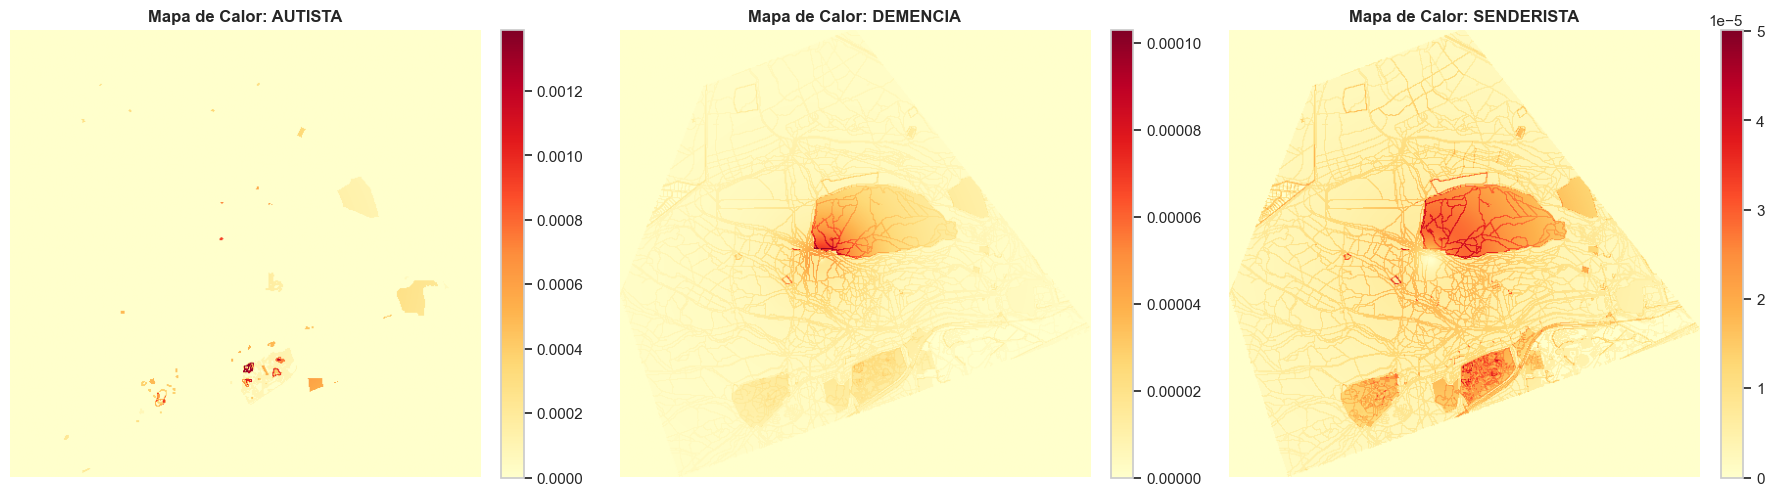

In [18]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Configuración de figura en paralelo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
perfiles = ["autista", "demencia", "senderista"]

for i, perfil in enumerate(perfiles):
    heatmap_path = f"TFM_JC/resultados/casa_de_campo_{perfil}/heatmap.npy"
    if os.path.exists(heatmap_path):
        heatmap = np.load(heatmap_path)
        im = axes[i].imshow(heatmap, cmap="YlOrRd", origin="lower")
        axes[i].set_title(f"Mapa de Calor: {perfil.upper()}", fontsize=12, fontweight="bold")
        axes[i].axis("off")
        fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
    else:
        axes[i].text(0.5, 0.5, f"No se encontró\n{perfil}", ha='center', va='center')
        axes[i].set_title(f"{perfil.upper()} (Faltante)")
        
plt.tight_layout()
plt.show();

## Fase 4: El Middleware (Traducción de Mapas a Rejillas Locales de MTS)

El simulador **MTS** opera sobre un sistema de coordenadas discreto local $(X, Y)$ con origen $[0,0]$ en la esquina inferior izquierda. Por lo tanto, el middleware `generar_json_real.py` traduce las coordenadas UTM globales (proyectadas desde latitud y longitud) a celdas discretas de la rejilla, calculando de forma precisa la ubicación local del LKP (*Last Known Position* / Punto de Inicio) para los agentes y configurando los parámetros del dron.

In [ ]:
import subprocess

def ejecutar_middleware(nombre_perfil):
    """
    Invoca el script de middleware para transformar los datos de SAREnv al JSON de MTS.
    """
    geojson_path = f"TFM_JC/resultados/casa_de_campo_{nombre_perfil}/features.geojson"
    npy_path = f"TFM_JC/resultados/casa_de_campo_{nombre_perfil}/heatmap.npy"
    out_json = f"TFM_JC/resultados/casa_de_campo_{nombre_perfil}/escenario_{nombre_perfil}.json"
    
    # Argumentos para el middleware
    cmd = [
        sys.executable,
        "TFM_JC/scripts/generar_json_real.py",
        "--geojson", geojson_path,
        "--npy", npy_path,
        "--out", out_json,
        "--agents", "1",            # 1 Dron de búsqueda (evita colisiones en MTS)
        "--algorithm", "voraz-heur"   # Algoritmo base inicial
    ]
    
    print(f"Ejecutando middleware para: escenario_{nombre_perfil}...")
    res = subprocess.run(cmd, capture_output=True, text=True)
    if res.returncode == 0:
        print(f"¡JSON generado correctamente en!: {out_json}")
    else:
        print(f"Error al ejecutar middleware para {nombre_perfil}:\\n{res.stderr}")

# Ejecutar para los 3 perfiles
ejecutar_middleware("autista")
ejecutar_middleware("demencia")
ejecutar_middleware("senderista")

print("=== Fase 2 completada: Ficheros JSON de configuración listos para MTS ===")

## Fase 5: Lanzamiento de Simulaciones Masivas en MTS

Para analizar la variabilidad estadística, ejecutamos **50 simulaciones independientes (semillas 0-49)** para cada perfil (Autista, Demencia, Senderista) y cada algoritmo de búsqueda:
1. **Greedy (Voraz Heurístico)**
2. **ACO (Optimización por Colonia de Hormigas)**
3. **ABC (Colonia de Abejas Artificiales)**
4. **BHA (Algoritmo de Agujero Negro)**

     "El script modifica dinámicamente los parámetros \"algoritmo_busqueda\" y \"semilla\" en el JSON correspondiente y ejecuta `bf-busqueda.py` con la animación desactivada (`\"dibujar_animacion\": False`) para acelerar el procesamiento headless."

In [ ]:
import json
import os
import sys
import subprocess

# ==============================================================================
# CONFIGURACIÓN GLOBAL DE PARÁMETROS DEL BENCHMARK (MONTECARLO MASIVO)
# ==============================================================================
num_semillas = 50             # Número de ejecuciones independientes por caso (0-49)
bateria_pasos = 1000          # Batería o límite de pasos por vuelo
num_drones = 1                # Número de agentes drones

# MODO DE POSICIONAMIENTO DEL OBJETIVO (VÍCTIMA)
# goal_pos = None             # MODO ALEATORIO: Muestreo probabilístico según el heatmap (Recomendado)
# goal_pos = [103, 132]       # MODO FIJO: Víctima estática en coordenadas locales específicas (ej: Zoo)
goal_pos = None

# PARÁMETROS DEL SENSOR (CÁMARA)
pdmax = 0.8                   # Probabilidad máxima de detección
dmax = 2.1                    # Rango máximo de detección en celdas (25m de radio)
sigma = 0.7                   # Caída exponencial de sensibilidad
# ==============================================================================

MTS_DIR = os.path.abspath("../..")

def lanzar_benchmark_simulaciones(semillas_count=50):
    """
    Ejecuta en lote todas las combinaciones de perfiles, algoritmos y semillas
    inyectando los parámetros globales de la celda.
    """
    perfiles = ["autista", "demencia", "senderista"]
    algoritmos = ["voraz-heur", "ACO", "ABC", "BHA", "lawnmower", "expanding_sq"]
    semillas = range(semillas_count)
    
    total_runs = len(perfiles) * len(algoritmos) * semillas_count
    print(f"Iniciando benchmark masivo en {MTS_DIR}.")
    print(f"Total de ejecuciones planeadas: {total_runs}\\n")
    
    for perfil in perfiles:
        json_path = os.path.abspath(f"TFM_JC/resultados/casa_de_campo_{perfil}/escenario_{perfil}.json")
        
        # Leer la configuración base
        with open(json_path, "r", encoding="utf-8") as f:
            config = json.load(f)
            
        # Configurar para ejecución desatendida/headless e inyectar parámetros de la celda
        config["dibujar_animacion"] = False
        config["show_evolution"] = False
        config["num_steps"] = bateria_pasos
        config["num_agents"] = num_drones
        config["pdmax"] = pdmax
        config["dmax"] = dmax
        config["sigma"] = sigma
        
        # Inyectar posición del objetivo (víctima)
        if goal_pos is None:
            config["obj_pos"] = [None]
        else:
            config["obj_pos"] = goal_pos
            
        # Si hay más de un agente, reposicionamos en diagonal para evitar colisiones iniciales
        if num_drones > 1:
            lkp_x, lkp_y = config["init_pos"][0]
            config["init_pos"] = [[lkp_x + i*2, lkp_y + i*2] for i in range(num_drones)]
        
        print(f"===============================================")
        print(f"Iniciando simulaciones para el Perfil: {perfil.upper()}")
        print(f"===============================================")
        
        for alg in algoritmos:
            print(f"-> Ejecutando algoritmo: {alg}...")
            for seed in semillas:
                # Modificar configuración temporalmente para el run actual
                config["algoritmo_busqueda"] = alg
                config["semilla"] = seed
                
                # Guardar en caliente para que bf-busqueda.py lo lea
                with open(json_path, "w", encoding="utf-8") as f:
                    json.dump(config, f, indent=4)
                
                # Lanzar el proceso de búsqueda en MTS
                cmd = [sys.executable, "bf-busqueda.py", json_path]
                res = subprocess.run(cmd, cwd=MTS_DIR, capture_output=True, text=True)
                
                if res.returncode != 0:
                    print(f"   [ERROR] Falló semilla {seed} de {alg}: {res.stderr}")
                    break
            print(f"   Completadas las {semillas_count} semillas para {alg}.")

# Lanzar el benchmark con el número de semillas configurado arriba
lanzar_benchmark_simulaciones(num_semillas)
print("\\n=== Fase 5 completada: Simulaciones masivas finalizadas. Trayectorias guardadas en disco. ===")

## Fase 6: Siembra de Víctimas de Montecarlo con Restricciones Geográficas

Para evaluar el desempeño científico, sembramos **1000 posiciones virtuales de víctimas** por perfil. Hacemos dos siembras distintas:
1. **Búsqueda Informada:** Posiciones generadas mediante muestreo probabilístico del heatmap bayesiano. Las víctimas aparecen en zonas de alta probabilidad estadística (ej. cerca de estructuras y lagos para el perfil Autista).
2. **Búsqueda Ciega (Línea de Base):** Posiciones distribuidas de forma totalmente uniforme por el polígono de la Casa de Campo.

**Restricciones de Transitabilidad a Pie (Filtros Físicos):** El generador realiza un filtrado espacial por índice geográfico (`sindex`) descartando cualquier posición que caiga dentro de polígonos de agua profunda (`water`) o edificaciones sólidas (`structure`) para evitar víctimas virtuales ahogadas o atrapadas en muros.

In [ ]:
import os
import json
import numpy as np
import geopandas as gpd
import shapely.geometry
from shapely.geometry import Point

def generar_y_guardar_victimas_montecarlo(nombre_perfil, n_victimas=1000):
    """
    Genera 1000 víctimas informadas y 1000 ciegas aplicando restricciones físicas de agua y estructuras.
    """
    output_dir = f"TFM_JC/resultados/casa_de_campo_{nombre_perfil}"
    geojson_path = os.path.join(output_dir, "features.geojson")
    heatmap_path = os.path.join(output_dir, "heatmap.npy")
    
    # Cargar metadatos y features
    with open(geojson_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    
    bounds = metadata["bounds"]  # [minx, miny, maxx, maxy] en UTM
    center_point = metadata["center_point"]
    meter_per_bin = metadata["meter_per_bin"]
    
    # Proyección UTM de la Casa de Campo
    lon, lat = center_point
    zone = int((lon + 180) / 6) + 1
    epsg = f"EPSG:326{zone}" if lat >= 0 else f"EPSG:327{zone}"
    
    # Cargar el GeoJSON y reproyectar a UTM
    gdf = gpd.read_file(geojson_path).to_crs(epsg)
    heatmap = np.load(heatmap_path)
    
    # Identificar capas físicas restrictivas
    water_bodies = gdf[gdf["feature_type"] == "water"]
    structures = gdf[gdf["feature_type"] == "structure"]
    
    minx, miny, _, _ = bounds
    
    # 1. GENERACIÓN DE VÍCTIMAS INFORMADAS (Por Heatmap)
    flat_heatmap = heatmap.flatten()
    flat_indices = np.arange(len(flat_heatmap))
    probs = flat_heatmap / np.sum(flat_heatmap)
    
    informadas = []
    intentos = 0
    while len(informadas) < n_victimas and intentos < 100:
        # Muestreamos lotes grandes para eficiencia espacial
        batch = np.random.choice(flat_indices, size=(n_victimas - len(informadas)) * 5, p=probs)
        for idx in batch:
            y_idx, x_idx = np.unravel_index(idx, heatmap.shape)
            x_utm = minx + x_idx * meter_per_bin + 0.5 * meter_per_bin
            y_utm = miny + y_idx * meter_per_bin + 0.5 * meter_per_bin
            pt = Point(x_utm, y_utm)
            
            # Filtros de transitabilidad
            in_water = False
            if not water_bodies.empty:
                matches = water_bodies.sindex.query(pt, predicate="intersects")
                if len(matches) > 0 and any(water_bodies.iloc[matches].intersects(pt)):
                    in_water = True
            
            in_struct = False
            if not structures.empty:
                matches = structures.sindex.query(pt, predicate="intersects")
                if len(matches) > 0 and any(structures.iloc[matches].intersects(pt)):
                    in_struct = True
            
            if not in_water and not in_struct:
                informadas.append(pt)
                if len(informadas) == n_victimas:
                    break
        intentos += 1
        
    # 2. GENERACIÓN DE VÍCTIMAS CIEGAS (Uniforme en Casa de Campo)
    casa_de_campo_utm = gpd.GeoDataFrame(geometry=[CASA_DE_CAMPO_POLY], crs="EPSG:4326").to_crs(epsg).geometry.iloc[0]
    c_minx, c_miny, c_maxx, c_maxy = casa_de_campo_utm.bounds
    
    ciegas = []
    intentos = 0
    while len(ciegas) < n_victimas and intentos < 100:
        xs = np.random.uniform(c_minx, c_maxx, size=(n_victimas - len(ciegas)) * 10)
        ys = np.random.uniform(c_miny, c_maxy, size=(n_victimas - len(ciegas)) * 10)
        for x_val, y_val in zip(xs, ys):
            pt = Point(x_val, y_val)
            
            if not casa_de_campo_utm.contains(pt):
                continue
                
            in_water = False
            if not water_bodies.empty:
                matches = water_bodies.sindex.query(pt, predicate="intersects")
                if len(matches) > 0 and any(water_bodies.iloc[matches].intersects(pt)):
                    in_water = True
            
            in_struct = False
            if not structures.empty:
                matches = structures.sindex.query(pt, predicate="intersects")
                if len(matches) > 0 and any(structures.iloc[matches].intersects(pt)):
                    in_struct = True
            
            if not in_water and not in_struct:
                ciegas.append(pt)
                if len(ciegas) == n_victimas:
                    break
        intentos += 1
        
    # Guardar en formato GeoJSON para auditoría visual e inyección en el evaluador
    gdf_inf = gpd.GeoDataFrame(geometry=informadas, crs=epsg)
    gdf_inf.to_file(os.path.join(output_dir, "victimas_informadas.geojson"), driver="GeoJSON")
    
    gdf_blind = gpd.GeoDataFrame(geometry=ciegas, crs=epsg)
    gdf_blind.to_file(os.path.join(output_dir, "victimas_ciegas.geojson"), driver="GeoJSON")
    
    print(f"Perfil {nombre_perfil.upper()}: 1000 víctimas informadas y 1000 ciegas generadas con éxito.")

# Generar para los 3 escenarios
generar_y_guardar_victimas_montecarlo("autista")
generar_y_guardar_victimas_montecarlo("demencia")
generar_y_guardar_victimas_montecarlo("senderista")

print("=== Fase 4 completada: Siembras de Montecarlo listas para evaluación ===")

## Fase 7: Módulo Evaluador del Benchmark (SAREnv PathEvaluator)

Evaluamos formalmente las trayectorias de drones salvadas de MTS utilizando el motor `PathEvaluator` de SAREnv. El dron vuela a **$H = 50\text{ m}$** con una cámara de **$FOV = 90^{\circ}$** ($R_{\text{det}} = 50\text{ m}$). Proyectamos la trayectoria del dron a UTM y ejecutamos la evaluación contra los dos sets de víctimas para obtener las 5 métricas académicas de la memoria:

1. **Tasa de Acierto (Success Rate):** Porcentaje de víctimas detectadas dentro del radio de 50 metros.
2. **Distancia de Vuelo (Flight Distance):** Longitud total recorrida por el dron en kilómetros.
3. **Tiempo Empleado (Steps Taken):** Número de pasos de la trayectoria.
4. **Área Cubierta (Area Covered):** Superficie barrida por la cámara en $km^2$ (evitando solapamientos).
5. **Likelihood Score:** Suma de probabilidades de las celdas barridas por el sensor.

In [ ]:
import glob
import pandas as pd
from shapely.geometry import LineString
from sarenv.analytics.metrics import PathEvaluator

def evaluar_todas_las_pruebas():
    """
    Carga todas las trayectorias JSON guardadas por MTS y calcula las métricas usando PathEvaluator.
    """
    perfiles = ["autista", "demencia", "senderista"]
    # Los nombres de archivos creados por el wrapper unificado de MTS
    mapeo_alg = {
        "voraz-heur": "voraz-heur",
        "ACO": "bf_aco_ET",
        "ABC": "bf_abc_ET",
        "BHA": "bf_bha_ET",
        "lawnmower": "lawnmower",
        "expanding_sq": "expanding"
    }
    
    resultados_filas = []
    
    for perfil in perfiles:
        output_dir = f"TFM_JC/resultados/casa_de_campo_{perfil}"
        geojson_path = os.path.join(output_dir, "features.geojson")
        heatmap_path = os.path.join(output_dir, "heatmap.npy")
        
        # Cargar mapa e información geográfica
        with open(geojson_path, "r", encoding="utf-8") as f:
            metadata = json.load(f)
        
        bounds = metadata["bounds"]  # [minx, miny, maxx, maxy]
        center_point = metadata["center_point"]
        meter_per_bin = metadata["meter_per_bin"]
        
        lon, lat = center_point
        zone = int((lon + 180) / 6) + 1
        epsg = f"EPSG:326{zone}" if lat >= 0 else f"EPSG:327{zone}"
        
        heatmap = np.load(heatmap_path)
        
        # Cargar las víctimas previamente guardadas
        g_inf = gpd.read_file(os.path.join(output_dir, "victimas_informadas.geojson"))
        g_blind = gpd.read_file(os.path.join(output_dir, "victimas_ciegas.geojson"))
        
        # Instanciar los evaluadores de SAREnv (uno para informadas y otro para ciegas)
        pe_inf = PathEvaluator(
            heatmap=heatmap,
            extent=bounds,
            victims=g_inf,
            fov_deg=90.0,      # FOV de la memoria
            altitude=50.0,     # Altitud de la memoria
            meters_per_bin=meter_per_bin
        )
        
        pe_blind = PathEvaluator(
            heatmap=heatmap,
            extent=bounds,
            victims=g_blind,
            fov_deg=90.0,
            altitude=50.0,
            meters_per_bin=meter_per_bin
        )
        
        # Directorio donde MTS guardó los resultados de la simulación
        # Nota que MTS genera la carpeta named after the JSON name: 'escenario_<perfil>'
        resultados_dir = f"TFM_JC/resultados/escenario_{perfil}"
        
        minx, miny, _, _ = bounds
        
        print(f"Evaluando resultados en: {resultados_dir}...")
        
        for alg_display, alg_file in mapeo_alg.items():
            # Buscar todas las trayectorias detalladas de este algoritmo
            pattern = os.path.join(resultados_dir, f"{alg_file}-*-traj.json")
            traj_files = glob.glob(pattern)
            
            if not traj_files:
                print(f"   [AVISO] No se encontraron archivos de trayectorias para {alg_display} ({pattern})")
                continue
                
            for t_file in traj_files:
                # Obtener la semilla desde el nombre de archivo
                base = os.path.basename(t_file)
                seed = int(base.split("-")[-2])
                
                # Cargar trayectoria discreta
                with open(t_file, "r", encoding="utf-8") as f:
                    data_t = json.load(f)
                
                list_x = data_t["list_x"][0]
                list_y = data_t["list_y"][0]
                
                # Transformar a UTM georreferenciadas
                coords = []
                for x_idx, y_idx in zip(list_x, list_y):
                    x_utm = minx + x_idx * meter_per_bin + 0.5 * meter_per_bin
                    y_utm = miny + y_idx * meter_per_bin + 0.5 * meter_per_bin
                    coords.append((x_utm, y_utm))
                
                if len(coords) < 2:
                    linea_dron = LineString([coords[0], coords[0]]) if coords else LineString()
                else:
                    linea_dron = LineString(coords)
                
                # Evaluar contra víctimas INFORMADAS
                res_inf = pe_inf.calculate_all_metrics([linea_dron], discount_factor=0.999)
                
                # Evaluar contra víctimas CIEGAS (Aleatorias)
                res_blind = pe_blind.calculate_all_metrics([linea_dron], discount_factor=0.999)
                
                # Registrar resultados para análisis de varianza
                resultados_filas.append({
                    "Perfil": perfil,
                    "Algoritmo": alg_display,
                    "Semilla": seed,
                    "Pasos": len(list_x) - 1,
                    "Distancia_km": res_inf["total_path_length"],
                    "Area_Covered_km2": res_inf["area_covered"],
                    "Likelihood_Score": res_inf["total_likelihood_score"],
                    "Acierto_Informada": res_inf["victim_detection_metrics"]["percentage_found"],
                    "Acierto_Ciega": res_blind["victim_detection_metrics"]["percentage_found"]
                })
                
    # Crear Dataframe de resultados globales
    df_global = pd.DataFrame(resultados_filas)
    df_global.to_csv("TFM_JC/resultados/resultados_evaluacion_tfm.csv", index=False)
    print(f"\n¡Evaluación finalizada! Tabla general de resultados guardada en: TFM_JC/resultados/resultados_evaluacion_tfm.csv")
    return df_global

df_eval = evaluar_todas_las_pruebas()
df_eval.head(10)

## Fase 8: Análisis Comparativo e Informes Académicos

Agrupamos y resumimos los resultados para obtener la media y la desviación típica de cada métrica. Esta celda compila directamente los datos agregados en el formato científico de tablas LaTeX listo para adjuntar al capítulo 5 de tu memoria.

In [ ]:
# Agrupar por Perfil y Algoritmo para obtener estadísticas descriptivas
resumen = df_eval.groupby(["Perfil", "Algoritmo"]).agg({
    "Acierto_Informada": ["mean", "std"],
    "Acierto_Ciega": ["mean", "std"],
    "Likelihood_Score": ["mean", "std"],
    "Distancia_km": ["mean", "std"],
    "Area_Covered_km2": ["mean", "std"]
})

# Formatear columnas
resumen.columns = [f"{col[0]}_{col[1]}" for col in resumen.columns.values]
resumen = resumen.reset_index()

print("=== ESTADÍSTICAS COMPARATIVAS DEL BENCHMARK ===")
display(resumen)

print("\n=== CÓDIGO TABLA LATEX PARA MEMORIA ===")
# Generar código LaTeX limpio
for perfil in resumen["Perfil"].unique():
    sub = resumen[resumen["Perfil"] == perfil]
    alg_map_latex = {
        "voraz-heur": "Voraz Heur.",
        "ACO": "ACO (Ants)",
        "ABC": "ABC (Bees)",
        "BHA": "BHA (BlackH)",
        "lawnmower": "Lawnmower",
        "expanding_sq": "Expanding Sq."
    }
    sub["Algoritmo_Display"] = sub["Algoritmo"].map(alg_map_latex)
    ord_algs = ["Voraz Heur.", "ACO (Ants)", "ABC (Bees)", "BHA (BlackH)", "Lawnmower", "Expanding Sq."]
    sub = sub.set_index("Algoritmo_Display").reindex(ord_algs).reset_index()
    
    print(f"\n% Tabla de resultados para perfil: {perfil.upper()}")
    print("\\begin{table}[h!]")
    print("\\centering")
    print("\\begin{tabular}{lccccc}")
    print("\\hline")
    print("Algoritmo & % Acierto (Inf.) & % Acierto (Ciego) & Likelihood Score & Distancia (km) & Área (km$^2$) \\\\")
    print("\\hline")
    for idx, row in sub.iterrows():
        print(f"\\textit{{{row['Algoritmo_Display']}}} & "
              f"{row['Acierto_Informada_mean']:.2f} \\pm {row['Acierto_Informada_std']:.2f} \\% & "
              f"{row['Acierto_Ciega_mean']:.2f} \\pm {row['Acierto_Ciega_std']:.2f} \\% & "
              f"{row['Likelihood_Score_mean']:.4f} \\pm {row['Likelihood_Score_std']:.4f} & "
              f"{row['Distancia_km_mean']:.2f} \\pm {row['Distancia_km_std']:.2f} & "
              f"{row['Area_Covered_km2_mean']:.4f} \\pm {row['Area_Covered_km2_std']:.4f} \\\\")
    print("\\hline")
    print("\\end{tabular}")
    print(f"\\caption{{Resultados comparativos del perfil {perfil} (Media \\pm Desviación Estándar) en la Casa de Campo.}}")
    print(f"\\label{{tab:resultados_{perfil}}}")
    print("\\end{table}")

## Fase 9: Generación de Gráficas de Rendimiento (Publicación)

Por último, generamos diagramas de caja (*Boxplots*) que ilustran de forma visual la distribución de las tasas de acierto bajo búsqueda informada frente a la ciega para demostrar de forma robusta la validez de los mapas de calor bayesianos en el enrutamiento SAR.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

perfiles = ["autista", "demencia", "senderista"]

for i, perfil in enumerate(perfiles):
    sub_df = df_eval[df_eval["Perfil"] == perfil]
    
    # Reformatear a formato largo (tidy data) para graficar con Seaborn
    df_melt = sub_df.melt(
        id_vars=["Algoritmo"], 
        value_vars=["Acierto_Informada", "Acierto_Ciega"], 
        var_name="Tipo de Búsqueda", 
        value_name="Tasa de Acierto (%)"
    )
    df_melt["Tipo de Búsqueda"] = df_melt["Tipo de Búsqueda"].map({
        "Acierto_Informada": "Informada (Bayesiana)",
        "Acierto_Ciega": "Ciega (Uniforme)"
    })
    
    alg_map_display = {
        "voraz-heur": "Voraz",
        "ACO": "ACO",
        "ABC": "ABC",
        "BHA": "BHA",
        "lawnmower": "Lawnm.",
        "expanding_sq": "Expand."
    }
    df_melt["Algoritmo"] = df_melt["Algoritmo"].map(alg_map_display)
    
    sns.boxplot(
        data=df_melt, 
        x="Algoritmo", 
        y="Tasa de Acierto (%)", 
        hue="Tipo de Búsqueda", 
        ax=axes[i],
        palette="Set2",
        order=["Voraz", "ACO", "ABC", "BHA", "Lawnm.", "Expand."]
    )
    axes[i].set_title(f"Perfil: {perfil.upper()}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Algoritmo de Búsqueda", fontsize=12)
    if i == 0:
        axes[i].set_ylabel("Tasa de Acierto (%)", fontsize=12)
    else:
        axes[i].set_ylabel("")
        
plt.tight_layout()
os.makedirs("TFM_JC/resultados/graficas", exist_ok=True)
graph_path = "TFM_JC/resultados/graficas/comparativa_acierto_perfiles.png"
plt.savefig(graph_path, dpi=300)
plt.show()
print(f"Gráfica comparativa guardada con éxito en: {graph_path}")